In [2]:
pip install yfinance

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [3]:
import yfinance as yf
print('yfinance is ready')

yfinance is ready


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from tqdm import tqdm

import math
import random
import warnings
warnings.filterwarnings('ignore')

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

In [6]:
TICKER = 'AAPL'

START_DATE = '2015-01-01'
END_DATE = '2025-01-01'

df = yf.download(TICKER, start=START_DATE, end=END_DATE, progress=False, auto_adjust=False)
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2015-01-02,24.171755,27.332500,27.860001,26.837500,27.847500,212818400
2015-01-05,23.490801,26.562500,27.162500,26.352501,27.072500,257142000
2015-01-06,23.493011,26.565001,26.857500,26.157499,26.635000,263188400
2015-01-07,23.822435,26.937500,27.049999,26.674999,26.799999,160423600
2015-01-08,24.737743,27.972500,28.037500,27.174999,27.307501,237458000


In [7]:
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

In [8]:
df = df.reset_index()

In [9]:
df.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
0,2015-01-02,24.171755,27.332500,27.860001,26.837500,27.847500,212818400
1,2015-01-05,23.490801,26.562500,27.162500,26.352501,27.072500,257142000
2,2015-01-06,23.493011,26.565001,26.857500,26.157499,26.635000,263188400
3,2015-01-07,23.822435,26.937500,27.049999,26.674999,26.799999,160423600
4,2015-01-08,24.737743,27.972500,28.037500,27.174999,27.307501,237458000


In [10]:
df.shape

(2516, 7)

In [11]:
df.columns

Index(['Date', 'Adj Close', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [12]:
df.dtypes

Price
Date         datetime64[ns]
Adj Close           float64
Close               float64
High                float64
Low                 float64
Open                float64
Volume                int64
dtype: object

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2516 entries, 0 to 2515
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       2516 non-null   datetime64[ns]
 1   Adj Close  2516 non-null   float64       
 2   Close      2516 non-null   float64       
 3   High       2516 non-null   float64       
 4   Low        2516 non-null   float64       
 5   Open       2516 non-null   float64       
 6   Volume     2516 non-null   int64         
dtypes: datetime64[ns](1), float64(5), int64(1)
memory usage: 137.7 KB


In [14]:
df.describe()

Price,Date,Adj Close,Close,High,Low,Open,Volume
count,2516,2516.000000,2516.000000,2516.000000,2516.000000,2516.000000,2.516000e+03
mean,2019-12-31 19:03:31.764706048,93.604149,96.363971,97.299699,95.323938,96.275646,1.170853e+08
min,2015-01-02 00:00:00,20.548149,22.584999,22.917500,22.367500,22.500000,2.323470e+07
25%,2017-07-02 06:00:00,35.127337,37.639375,38.040001,37.295626,37.606874,7.105610e+07
50%,2020-01-01 00:00:00,64.213238,66.661251,67.281250,65.807503,66.549999,1.003646e+08
75%,2022-06-30 06:00:00,149.826164,152.772503,154.564999,150.812504,152.572506,1.426216e+08
max,2024-12-31 00:00:00,257.153809,259.019989,260.100006,257.630005,258.190002,6.488252e+08
std,NaN,65.263645,65.255230,65.849313,64.567788,65.174986,6.839614e+07


In [15]:
df.isna().sum()

Price
Date         0
Adj Close    0
Close        0
High         0
Low          0
Open         0
Volume       0
dtype: int64

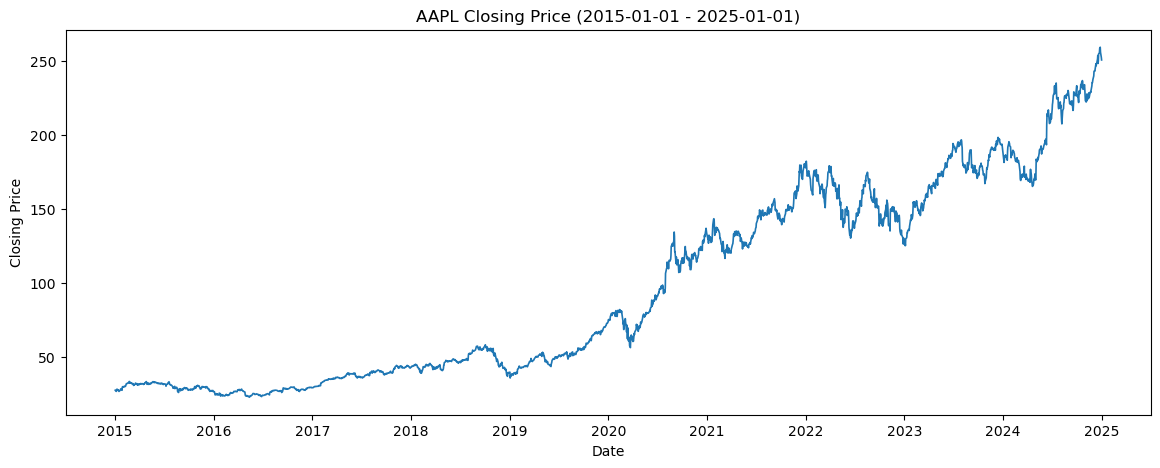

In [16]:
plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], linewidth=1.2)
plt.title(f"{TICKER} Closing Price ({START_DATE} - {END_DATE})")
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.show()

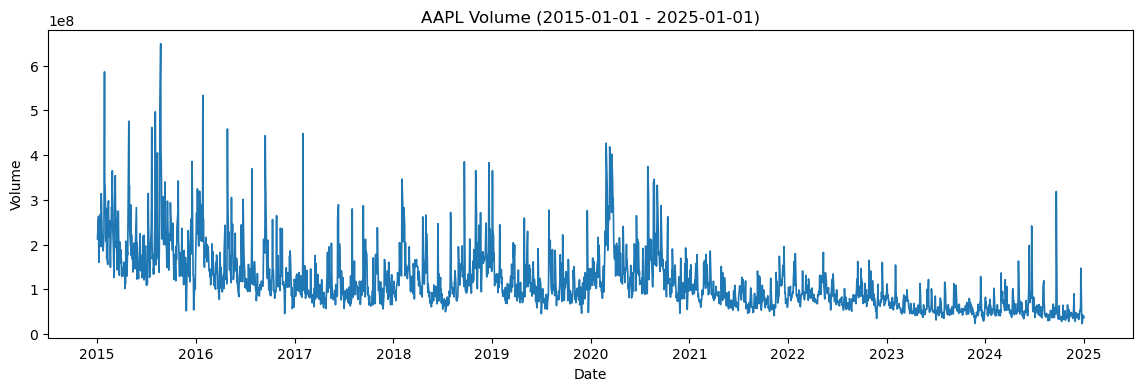

In [17]:
plt.figure(figsize=(14, 4))
plt.plot(df['Date'], df['Volume'], linewidth=1.2)
plt.title(f"{TICKER} Volume ({START_DATE} - {END_DATE})")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

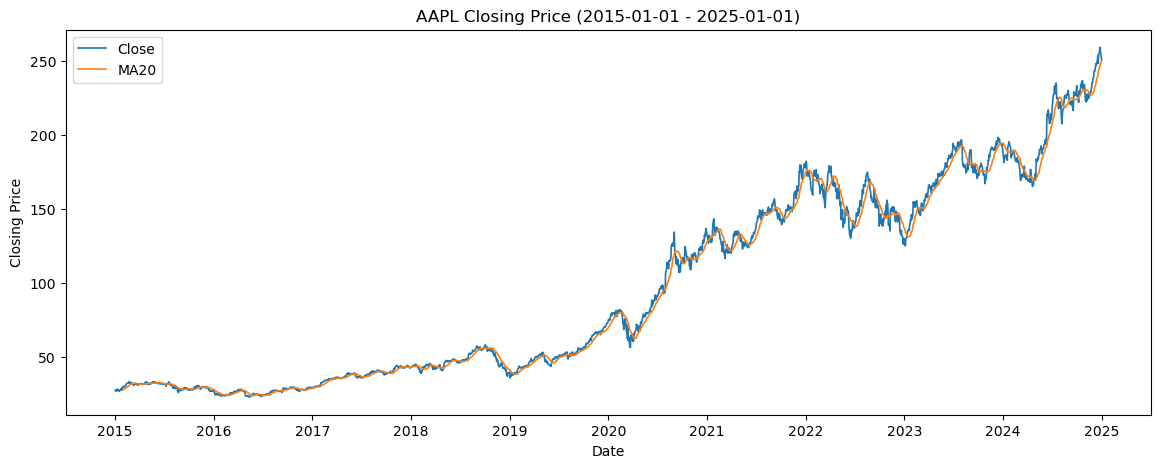

In [18]:
df['MA20'] = df['Close'].rolling(20).mean()

plt.figure(figsize=(14, 5))
plt.plot(df['Date'], df['Close'], linewidth=1.2, label='Close')
plt.plot(df['Date'], df['MA20'], linewidth=1.2, label='MA20')
plt.title(f"{TICKER} Closing Price ({START_DATE} - {END_DATE})")
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.show()

In [19]:
df

Price,Date,Adj Close,Close,High,Low,Open,Volume,MA20
0,2015-01-02,24.171755,27.332500,27.860001,26.837500,27.847500,212818400,NaN
1,2015-01-05,23.490801,26.562500,27.162500,26.352501,27.072500,257142000,NaN
2,2015-01-06,23.493011,26.565001,26.857500,26.157499,26.635000,263188400,NaN
3,2015-01-07,23.822435,26.937500,27.049999,26.674999,26.799999,160423600,NaN
4,2015-01-08,24.737743,27.972500,28.037500,27.174999,27.307501,237458000,NaN
...,...,...,...,...,...,...,...,...
2511,2024-12-24,256.339752,258.200012,258.209991,255.289993,255.490005,23234700,246.293500
2512,2024-12-26,257.153809,259.019989,260.100006,257.630005,258.190002,27237100,247.491499
2513,2024-12-27,253.748535,255.589996,258.700012,253.059998,257.829987,42355300,248.524500
2514,2024-12-30,250.382965,252.199997,253.500000,250.750000,252.229996,35557500,249.267999


In [20]:
close_prices = df[['Close']].values

In [21]:
print(close_prices[:5])

[[27.33250046]
 [26.5625    ]
 [26.56500053]
 [26.9375    ]
 [27.97249985]]


In [24]:
demo_scaler = MinMaxScaler(feature_range=(0, 1))
demo_scaled = demo_scaler.fit_transform(close_prices)
print(demo_scaled[:5])

[[0.02007952]
 [0.01682281]
 [0.01683339]
 [0.01840887]
 [0.02278639]]


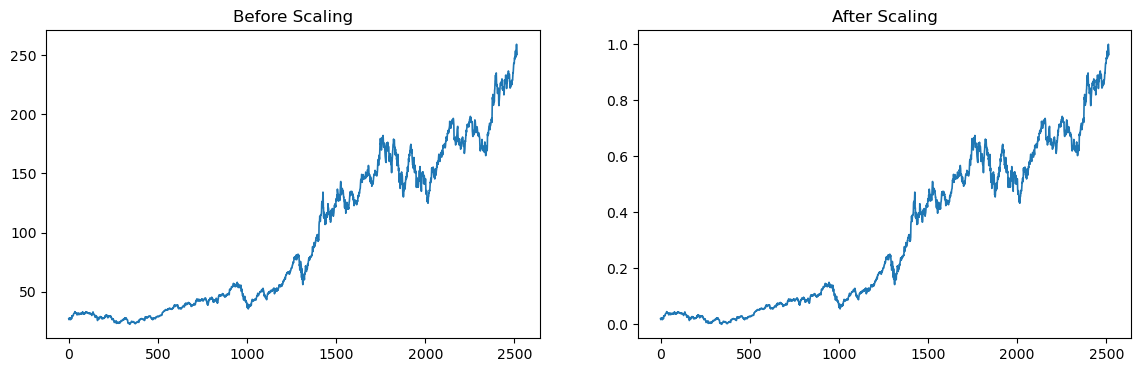

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(close_prices, linewidth=1.2)
axes[0].set_title('Before Scaling')
axes[1].plot(demo_scaled, linewidth=1.2)
axes[1].set_title('After Scaling')
plt.show()

In [26]:
SEQ_LEN = 60

def create_sequences(data: np.ndarray, seq_len: int):
    X, y = [], []

    for i in range(len(data) - seq_len):
        window = data[i : i + seq_len]
        target = data[i + seq_len]

        X.append(window)
        y.append(target)

    return np.array(X), np.array(y)

tiny_example = np.array([0.1, 0.2, 0.3, 0.4, 0.5, 0.6]).reshape(-1, 1)
tiny_X, tiny_y = create_sequences(tiny_example, seq_len=3)
print(tiny_X.squeeze())
print(tiny_y.squeeze())

[[0.1 0.2 0.3]
 [0.2 0.3 0.4]
 [0.3 0.4 0.5]]
[0.4 0.5 0.6]


In [27]:
train_size = int(len(close_prices) * 0.8)

train_raw = close_prices[:train_size]
test_raw = close_prices[train_size:]

print(f"Total days: {len(close_prices)}")
print(f"Train days: {len(train_raw)}")
print(f"Test days: {len(test_raw)}")

Total days: 2516
Train days: 2012
Test days: 504


In [28]:
scaler = MinMaxScaler(feature_range=(0, 1))
train_scaled = scaler.fit_transform(train_raw)
test_scaled = scaler.transform(test_raw)

In [29]:
print('Train scaled range:', train_scaled.min(), train_scaled.max())
print('Test scaled range:', test_scaled.min(),test_scaled.max())

Train scaled range: 0.0 1.0
Test scaled range: 0.6425278375402401 1.4830484348004151


In [30]:
X_train, y_train = create_sequences(train_scaled, SEQ_LEN)
X_test, y_test = create_sequences(test_scaled, SEQ_LEN)

print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(1952, 60, 1) (1952, 1)
(444, 60, 1) (444, 1)


In [31]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

In [34]:
class StockDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = StockDataset(X_train_tensor, y_train_tensor)
test_dataset = StockDataset(X_test_tensor, y_test_tensor)

In [35]:
BATCH_SIZE = 32
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [36]:
sample_X, sample_y = next(iter(train_loader))
print('One batch of X shape:', sample_X.shape)
print('One batch of y shape:', sample_y.shape)
print('Number of batch per epoch:', len(train_loader))

One batch of X shape: torch.Size([32, 60, 1])
One batch of y shape: torch.Size([32, 1])
Number of batch per epoch: 61


In [38]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1,hidden_size=64, num_layers=2, output_size=1, dropout=0.2):
        super(GRUModel, self).__init__()

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.dropout = nn.Dropout(dropout)

        self.fc = nn.Linear(hidden_size, output_size)

        def forward(self, x):
            out, h_n = self.gru(x)
            last_step_out = out[:,-1,:]
            last_step_out = self.dropout(last_step_out)
            prediction = self.fc(last_step_out)

            return prediction

INPUT_SIZE = 1
HIDDEN_SIZE = 64
NUM_LAYERS = 2
OUTPUT_SIZE = 1
DROPOUT = 0.2

model = GRUModel(
    input_size=INPUT_SIZE,
    hidden_size=HIDDEN_SIZE,
    num_layers=NUM_LAYERS,
    output_size=OUTPUT_SIZE,
    dropout=DROPOUT,
)

print(model)

GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)


In [39]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {total_params}")

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total number of trainable parameters: {trainable_params}")

Total number of parameters: 37889
Total number of trainable parameters: 37889


In [40]:
model.eval()

with torch.no_grad():
    sample_X, sample_y = next(iter(train_loader))
    print("1) Input shape:", sample_X.shape)

    gru_out, h_n = model.gru(sample_X)
    print("2) GRU output shape:", gru_out.shape)
    print("3) Final hidden stage shape:", h_n.shape)

    last_step = gru_out[:,-1,:]
    print("4) Last time step shape:", last_step.shape)

    prediction = model.fc(last_step)
    print("5) Prediction shape:", prediction.shape)

model.train()

1) Input shape: torch.Size([32, 60, 1])
2) GRU output shape: torch.Size([32, 60, 64])
3) Final hidden stage shape: torch.Size([2, 32, 64])
4) Last time step shape: torch.Size([32, 64])
5) Prediction shape: torch.Size([32, 1])


GRUModel(
  (gru): GRU(1, 64, num_layers=2, batch_first=True, dropout=0.2)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)